In [1]:
import torch
from torch import nn
print(torch.__version__)          # should now show the real version
print(torch.nn.Module)            # should work

2.10.0+cpu
<class 'torch.nn.modules.module.Module'>


In [2]:
import torchvision

In [3]:
import torchvision
from torchvision import datasets
from torchvision import transforms

In [4]:
from torchvision.transforms import ToTensor
from torchvision.transforms.functional import adjust_contrast
from torchvision.transforms.functional import rgb_to_grayscale
from torchvision.transforms.functional import resize
from torchvision.transforms.functional import adjust_saturation

In [5]:
import matplotlib.pyplot as plt


from timeit import default_timer as timer

import tqdm
from tqdm.auto import tqdm



print("ready")

ready


B:\anaconda\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## project components


### visuals


In [6]:
def show_dataset(images, lables):
    fig = plt.figure(figsize=(9, 5))
    rows, cols = 4, 8
    
    for i in range(0, rows*cols):
        img = images[i]
        label = lables[i]

        img = rgb_to_grayscale(img)
        img = adjust_contrast(img, 1.5)
        
    
        fig.add_subplot(rows, cols, i+1)
        img = torch.permute(img, (1, 2, 0))
        plt.imshow(img.squeeze(), cmap = "gray")
        
        plt.title(class_names[label])
        plt.axis(False)
        
        

### helpfull functions


In [7]:
def accuracy(y_real, y_pred):
    
    correct = torch.eq(y_real, y_pred).sum().item()
    
    acc = (correct/len(y_pred)) * 100

    return acc

In [8]:
def print_train_time(start: float, end: float, device: torch.device = None):
    
    time = end - start
    print(f"Train time on {device} is: {time: .4f}")
    return time

### traing/test functions


In [9]:
def train(model, loss_fn, optimizer: str, lr: float, epoches: int):

    
    loss_fn = loss_fn

    if(optimizer.lower() == "adam"):
        optimizer = torch.optim.Adam(params = model.parameters(), lr = lr)
        
    else:
        optimizer = torch.optim.SGD(params = model.parameters(), lr = lr)

    
    for epoch in tqdm(range(epoches)):
        print(f"Epoch: {epoch}\n------")
        
    
        train_loss, train_acc = 0, 0
    
        for batch, (X, y) in enumerate(train_dataloader):
            
            model.train()
        
            y_pred = model(X.to("cpu"))
        
            loss = loss_fn(y_pred.to("cpu"), y.to("cpu"))
        
            train_loss += loss
            train_acc += accuracy(y_real = y.to("cpu"), y_pred = y_pred.argmax(dim=1).to("cpu"))
            
            optimizer.zero_grad()
        
            loss.backward()
        
            optimizer.step()
        
            if batch % 400 == 0:
                print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
        
        
        train_loss /= len(train_dataloader)
        
        train_acc /= len(train_dataloader)
    
        
        test_loss, test_acc = 0, 0
        model.eval()
    
        with torch.inference_mode():
            for X_test, y_test in test_dataloader:
                
                test_pred = model(X_test.to("cpu"))
    
                test_loss += loss_fn(test_pred.to("cpu"), y_test.to("cpu"))
    
                test_acc += accuracy(y_real = y_test.to("cpu"), y_pred = test_pred.argmax(dim=1).to("cpu"))
    
                
            test_loss  /= len(test_dataloader)
            test_acc   /= len(test_dataloader)
    
            
            print(f"\nTrain loss: {train_loss: .4f}, Train acc: {train_acc: .4f}  ||  Test loss: {test_loss: .4f}  Test acc: {test_acc: .4f}")
    
        time_end = timer()
    
        print_train_time(start = time_start, end = time_end, device = str(next(model_0.parameters()).device))

### DATA


In [10]:
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    download = True,
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    download = True,
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)

B:\anaconda\envs\torch\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [11]:
class_names = train_data.classes
class_names


['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

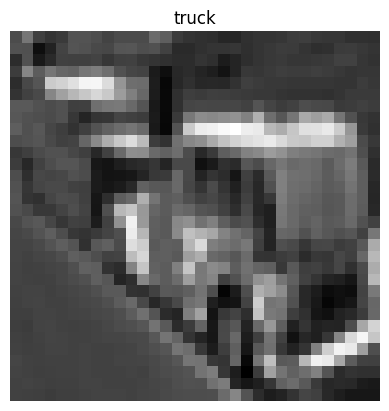

In [12]:
random_idx = torch.randint(0, len(train_data), size=[1]).item()

image_sample, image_sample_label = train_data[random_idx]

image_sample = rgb_to_grayscale(image_sample)
image_sample = torch.permute(image_sample, (1, 2, 0))
plt.imshow(image_sample.squeeze(), cmap = "gray")


plt.title(class_names[image_sample_label])
plt.axis(False)

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

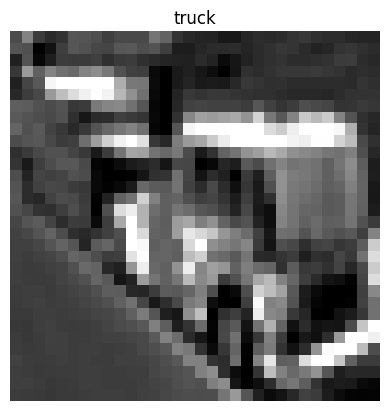

In [13]:
image_sample, image_sample_label = train_data[random_idx]


image_sample = rgb_to_grayscale(image_sample)
image_sample = adjust_contrast(image_sample, 1.5)






image_sample = torch.permute(image_sample, (1, 2, 0))
plt.imshow(image_sample.squeeze(), cmap = "gray")



plt.title(class_names[image_sample_label])
plt.axis(False)




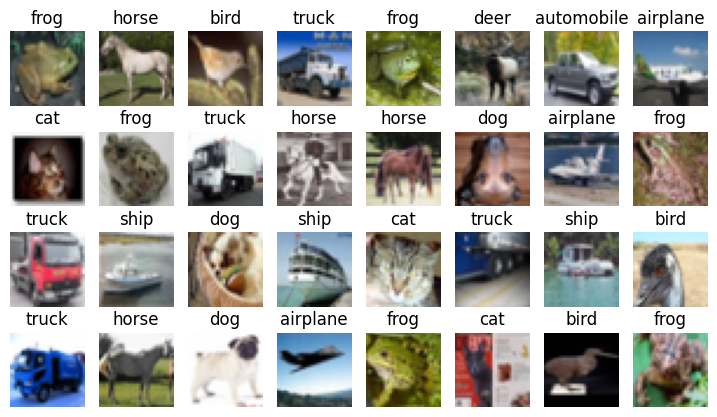

In [14]:
fig = plt.figure(figsize=(9, 5))
rows, cols = 4, 8



for i in range(1, rows*cols + 1):
    
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    img = torch.permute(img, (1, 2, 0))
    
    
    plt.imshow(img.squeeze(), cmap = "gray")
    plt.title(class_names[label])
    plt.axis(False)
    

    

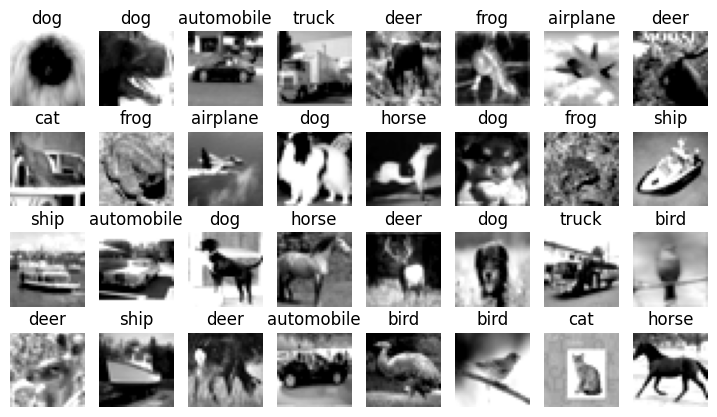

In [15]:
fig = plt.figure(figsize=(9, 5))
rows, cols = 4, 8



for i in range(1, rows*cols + 1):
    
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    
    img, label = train_data[random_idx]
    
    img = rgb_to_grayscale(img)
    img = adjust_contrast(img, 1.5)
    
    
    
    fig.add_subplot(rows, cols, i)
    img = torch.permute(img, (1, 2, 0))
    
    
    plt.imshow(img.squeeze(), cmap = "gray")
    plt.title(class_names[label])
    plt.axis(False)

    

## preparing data

In [16]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data, batch_size = BATCH_SIZE, shuffle = True)

test_dataloader = DataLoader(dataset = test_data, batch_size = BATCH_SIZE, shuffle = False)

train_dataloader, test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x2265c542270>,
 <torch.utils.data.dataloader.DataLoader at 0x2265d78d6d0>)

In [17]:
print(f"Data loader: {train_dataloader, test_dataloader}")
print(f"Lenght of train_dataloader: {len(train_dataloader)} bathes of: {BATCH_SIZE}")
print(f"Lenght of test_dataloader:  {len(test_dataloader)} bathes of: {BATCH_SIZE}")


Data loader: (<torch.utils.data.dataloader.DataLoader object at 0x000002265C542270>, <torch.utils.data.dataloader.DataLoader object at 0x000002265D78D6D0>)
Lenght of train_dataloader: 1563 bathes of: 32
Lenght of test_dataloader:  313 bathes of: 32


<>:9: SyntaxWarning: invalid escape sequence '\/'
<>:9: SyntaxWarning: invalid escape sequence '\/'
C:\Users\khan\AppData\Local\Temp\ipykernel_7584\1250902867.py:9: SyntaxWarning: invalid escape sequence '\/'
  print("                                                 \/ \n")


torch.Size([3, 32, 32])
train data batch shape: torch.Size([32, 3, 32, 32]) train labels batch shap: torch.Size([32]) 

                                          -----------------
                                          | Batch preview |
                                          ----------------- 

                                                 ||
                                                 ||
                                                 \/ 



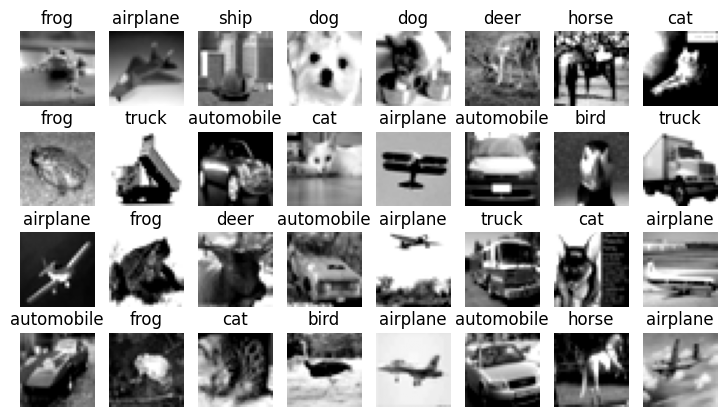

In [18]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(train_features_batch[0].size())
print(f"train data batch shape: {train_features_batch.shape} train labels batch shap: {train_labels_batch.shape} \n")
print("                                          -----------------")
print("                                          | Batch preview |")
print("                                          ----------------- \n")
print("                                                 ||")
print("                                                 ||")
print("                                                 \/ \n")
show_dataset(train_features_batch, train_labels_batch)



## WB + 8x8 color

In [19]:
class CVM_V2_multy_input(nn.Module):
    def __init__(self):
        super().__init__()

        self.First_conv = nn.Conv2d(1, 16, kernel_size=3, padding=2)
        self.Second_conv = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        
        self.Pool = nn.MaxPool2d(2, 2)

        self.First_linear = nn.Linear(in_features = 8*8*8 + 8*8*3, out_features = 16)
        self.Second_linear = nn.Linear(in_features = 16, out_features = 16)
        self.Third_linear = nn.Linear(in_features = 16, out_features = 10)
        
        self.Relu = nn.ReLU()
        self.LRelu = nn.LeakyReLU()
        
        self.Flat = nn.Flatten()
        self.Conv_drop = nn.Dropout(p = 0.05)
        self.Line_drop = nn.Dropout(p = 0.2)
        
 
    
    def forward(self, data):
        
        depth, colors = data
        
        depth = self.First_conv(depth)
        epth = self.Relu(depth)
        depth = self.Pool(depth)
        depth = self.Relu(depth)

        depth = self.Conv_drop(depth)

        depth = self.Second_conv(depth)
        epth = self.Relu(depth)
        depth = self.Pool(depth)
        depth = self.Relu(depth)

        depth = self.Conv_drop(depth)
        
        depth = self.Flat(depth)
        colors = self.Flat(colors)    
        
        depth = torch.cat((depth, colors), dim = 1)
        
        depth = self.LRelu(depth)
        depth = self.First_linear(depth)
        depth = self.Line_drop(depth)
        depth = self.LRelu(depth)
        depth = self.Second_linear(depth)
        depth = self.Line_drop(depth)
        depth = self.LRelu(depth)
        depth = self.Third_linear(depth)

        return depth

In [20]:
torch.manual_seed(47)

model_0 = CVM_V2_multy_input().to("cpu")

model_0

CVM_V2_multy_input(
  (First_conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
  (Second_conv): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (Pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (First_linear): Linear(in_features=704, out_features=16, bias=True)
  (Second_linear): Linear(in_features=16, out_features=16, bias=True)
  (Third_linear): Linear(in_features=16, out_features=10, bias=True)
  (Relu): ReLU()
  (LRelu): LeakyReLU(negative_slope=0.01)
  (Flat): Flatten(start_dim=1, end_dim=-1)
  (Conv_drop): Dropout(p=0.05, inplace=False)
  (Line_drop): Dropout(p=0.2, inplace=False)
)

In [39]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.001)


In [40]:
start_time = timer()

end_time = timer()

print_train_time(start = start_time, end = end_time, device = "cpu")

Train time on cpu is:  0.0000


2.289999997628911e-05

In [41]:
time_start = timer()

epoches = 10
for epoch in tqdm(range(epoches)):
    #print(f"Epoch: {epoch}\n------")

    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(train_dataloader):

        model_0.train()

        X_col = resize(X, size=(8, 8))
        X_col = adjust_saturation(X_col, 5)
        
        X = rgb_to_grayscale(X)
        X = adjust_contrast(X, 1.5)
        

        y_pred = model_0([X.to("cpu"), X_col.to("cpu")])

        loss = loss_fn(y_pred.to("cpu"), y.to("cpu"))

        train_loss += loss
        train_acc += accuracy(y_real = y.to("cpu"), y_pred = y_pred.argmax(dim=1).to("cpu"))
        
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    
    test_loss, test_acc = 0, 0
    model_0.eval()

    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            
            X_test_col = resize(X_test, size=(8,8))
            X_test_col = adjust_saturation(X_test_col, 5)
            
            X_test = rgb_to_grayscale(X_test)
            X_test = adjust_contrast(X_test, 1.5)
            
            
            test_pred = model_0([X_test.to("cpu"), X_test_col.to("cpu")])

            test_loss += loss_fn(test_pred.to("cpu"), y_test.to("cpu"))

            test_acc += accuracy(y_real = y_test.to("cpu"), y_pred = test_pred.argmax(dim=1).to("cpu"))

            
        test_loss  /= len(test_dataloader)
        test_acc   /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss: .4f}, Train acc: {train_acc: .4f}  ||  Test loss: {test_loss: .4f}  Test acc: {test_acc: .4f}")
    #print("============================================")

    
time_end = timer()

print_train_time(start = time_start, end = time_end, device = str(next(model_0.parameters()).device))

 10%|█         | 1/10 [00:12<01:51, 12.35s/it]


Train loss:  1.2298, Train acc:  56.5919  ||  Test loss:  1.1231  Test acc:  60.6829


 20%|██        | 2/10 [00:24<01:38, 12.27s/it]


Train loss:  1.2247, Train acc:  56.6639  ||  Test loss:  1.1224  Test acc:  60.7328


 30%|███       | 3/10 [00:36<01:26, 12.29s/it]

...

 90%|█████████ | 9/10 [01:50<00:12, 12.29s/it]


Train loss:  1.2264, Train acc:  56.6279  ||  Test loss:  1.1211  Test acc:  60.8526


100%|██████████| 10/10 [02:02<00:00, 12.30s/it]


Train loss:  1.2238, Train acc:  56.5839  ||  Test loss:  1.1188  Test acc:  60.8926
Train time on cpu is:  122.9627


122.96269010000015

2777


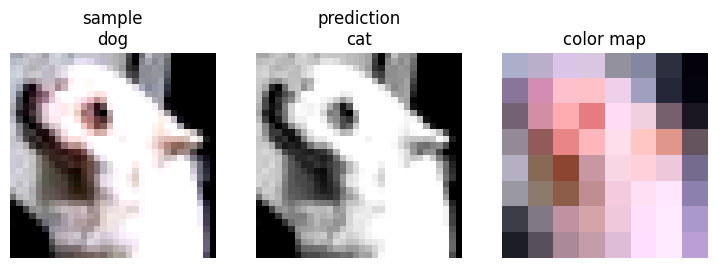

In [46]:
fig = plt.figure(figsize=(9, 3))
rows, cols = 1, 3

random_idx = torch.randint(0, len(test_data), size=[1]).item()

img, label = test_data[random_idx]
fig.add_subplot(rows, cols, 1)
img = adjust_contrast(img, 1.5)
img = torch.permute(img, (1, 2, 0))

plt.imshow(img.squeeze(), cmap = "gray")
plt.title("sample\n" + class_names[label])
plt.axis(False)

img, label = test_data[random_idx]
fig.add_subplot(rows, cols, 2)
img = rgb_to_grayscale(img)
img = adjust_contrast(img, 1.5)
img = torch.permute(img, (1, 2, 0))
plt.imshow(img.squeeze(), cmap = "gray")

img2, label = test_data[random_idx]

img2_col = resize(img2, size=(8,8))

img2 = rgb_to_grayscale(img2)
img2 = adjust_contrast(img2, 1.5)
img2 = img2.unsqueeze(0)
img2_col = img2_col.unsqueeze(0)

plt.axis(False)
pred = model_0([img2, img2_col])
result = pred.argmax(dim=1).item()

plt.title("prediction\n" + class_names[result])

img2, label = test_data[random_idx]

img2_col = resize(img2, size=(8, 8))
img2_col = adjust_saturation(img2_col, 5)

fig.add_subplot(rows, cols, 3)
img2_col = torch.permute(img2_col, (1, 2, 0))
plt.imshow(img2_col.squeeze(), cmap = "gray")
plt.axis(False)

plt.title("color map")

print(random_idx)

## full RGB input

In [47]:
class CVM_Full_RGB_input(nn.Module):
    def __init__(self):
        super().__init__()

        self.First_conv = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.Second_conv = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        
        self.Pool = nn.MaxPool2d(2, 2)

        self.First_linear = nn.Linear(in_features = 32*8*8, out_features = 64)
        self.Second_linear = nn.Linear(in_features = 64, out_features = 64)
        self.Third_linear = nn.Linear(in_features = 64, out_features = 10)
        
        self.Relu = nn.ReLU()
        self.LRelu = nn.LeakyReLU()
        
        self.Flat = nn.Flatten()
        self.Conv_drop = nn.Dropout(p = 0.05)
        self.Line_drop = nn.Dropout(p = 0.2)
        
 
    
    def forward(self, X):
        
        X = self.First_conv(X)
        X = self.Relu(X)
        X = self.Pool(X)
        X = self.Relu(X)

        X = self.Conv_drop(X)

        X = self.Second_conv(X)
        X = self.Relu(X)
        X = self.Pool(X)
        X = self.Relu(X)

        X = self.Conv_drop(X)
        
        X = self.Flat(X)
        
        X = self.LRelu(X)
        X = self.First_linear(X)
        X = self.Line_drop(X)
        X = self.LRelu(X)
        X = self.Second_linear(X)
        X = self.Line_drop(X)
        X = self.LRelu(X)
        X = self.Third_linear(X)

        return X

In [48]:
torch.manual_seed(47)

model_1 = CVM_Full_RGB_input().to("cpu")

model_1

CVM_Full_RGB_input(
  (First_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (Second_conv): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (Pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (First_linear): Linear(in_features=2048, out_features=64, bias=True)
  (Second_linear): Linear(in_features=64, out_features=64, bias=True)
  (Third_linear): Linear(in_features=64, out_features=10, bias=True)
  (Relu): ReLU()
  (LRelu): LeakyReLU(negative_slope=0.01)
  (Flat): Flatten(start_dim=1, end_dim=-1)
  (Conv_drop): Dropout(p=0.05, inplace=False)
  (Line_drop): Dropout(p=0.2, inplace=False)
)

In [52]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.01)

In [53]:
time_start = timer()

epoches = 10
for epoch in tqdm(range(epoches)):
    #print(f"Epoch: {epoch}\n------")

    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(train_dataloader):

        model_1.train()


        y_pred = model_1(X.to("cpu"))

        loss = loss_fn(y_pred.to("cpu"), y.to("cpu"))

        train_loss += loss
        train_acc += accuracy(y_real = y.to("cpu"), y_pred = y_pred.argmax(dim=1).to("cpu"))
        
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    
    test_loss, test_acc = 0, 0
    model_1.eval()

    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            
            
            
            
            test_pred = model_1(X_test.to("cpu"))

            test_loss += loss_fn(test_pred.to("cpu"), y_test.to("cpu"))

            test_acc += accuracy(y_real = y_test.to("cpu"), y_pred = test_pred.argmax(dim=1).to("cpu"))

            
        test_loss  /= len(test_dataloader)
        test_acc   /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss: .4f}, Train acc: {train_acc: .4f}  ||  Test loss: {test_loss: .4f}  Test acc: {test_acc: .4f}")
    #print("============================================")

    
time_end = timer()

print_train_time(start = time_start, end = time_end, device = str(next(model_0.parameters()).device))

 10%|█         | 1/10 [00:25<03:49, 25.51s/it]


Train loss:  0.5247, Train acc:  81.6559  ||  Test loss:  0.8739  Test acc:  72.1945


 20%|██        | 2/10 [00:51<03:24, 25.50s/it]


Train loss:  0.4951, Train acc:  82.5916  ||  Test loss:  0.8833  Test acc:  72.3243


 30%|███       | 3/10 [01:16<02:58, 25.46s/it]

...

 90%|█████████ | 9/10 [03:49<00:25, 25.48s/it]


Train loss:  0.4325, Train acc:  84.8349  ||  Test loss:  0.9161  Test acc:  72.3842


100%|██████████| 10/10 [04:14<00:00, 25.49s/it]


Train loss:  0.4341, Train acc:  84.6029  ||  Test loss:  0.9160  Test acc:  72.3842
Train time on cpu is:  254.9336


254.93359469999996

torch.Size([1, 3, 32, 32])
4346


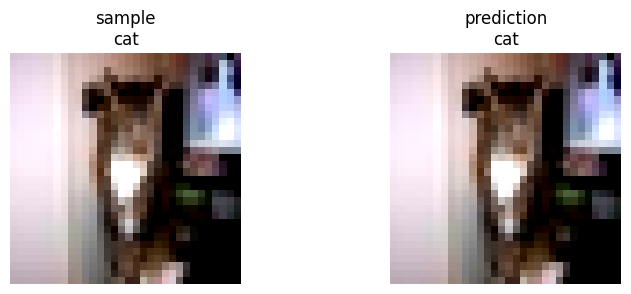

In [56]:
fig = plt.figure(figsize=(9, 3))
rows, cols = 1, 2

random_idx = torch.randint(0, len(test_data), size=[1]).item()

img, label = test_data[random_idx]
fig.add_subplot(rows, cols, 1)
img = adjust_contrast(img, 1.5)
img = torch.permute(img, (1, 2, 0))

plt.imshow(img.squeeze(), cmap = "gray")
plt.title("sample\n" + class_names[label])
plt.axis(False)

fig.add_subplot(rows, cols, 2)
plt.imshow(img.squeeze(), cmap = "gray")

img2, label = test_data[random_idx]


img2 = adjust_contrast(img2, 1.5)
img2 = img2.unsqueeze(0)

plt.axis(False)

print(img2.shape)

pred = model_1(img2)
result = pred.argmax(dim=1).item()

plt.title("prediction\n" + class_names[result])
print(random_idx)